# First-Visit Monte Carlo - Agente Connect-4

**Estudiante:** Mariana Valle Moreno  
**Curso:** Inteligencia Artificial  
**Agente:** `FVMC_mariana`

Este notebook contiene el estudio del agente basado en **First-Visit Monte Carlo (FVMC)**. El objetivo es validar el desempeño del agente contra un jugador aleatorio, analizar el efecto del número de partidas de entrenamiento y evaluar el comportamiento del agente jugando contra sí mismo.


## 1. Idea principal del agente

El agente utiliza **First-Visit Monte Carlo** para aprender una tabla Q a partir de partidas simuladas contra un jugador aleatorio.

Durante la ejecución de una partida, el agente sigue este flujo:

1. Si puede ganar inmediatamente, juega esa columna.
2. Si el oponente puede ganar en el siguiente turno, bloquea esa columna.
3. Si no hay una jugada inmediata, consulta la tabla Q aprendida.
4. Si el estado actual no está en la tabla Q, usa una estrategia base que prioriza las columnas centrales.

El aprendizaje se realiza de forma **offline**. Es decir, durante una partida real el agente no vuelve a entrenar, sino que usa la tabla `q_values.pkl` previamente generada.


## 2. Configuración inicial

In [1]:
# Importar las bibliotecas necesarias
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Buscar la raíz del proyecto
current_path = Path.cwd().resolve()
project_root = current_path

for parent in [current_path] + list(current_path.parents):
    if (parent / "connect4").exists() and (parent / "groups").exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: C:\Users\charj\AIProject


In [3]:
from connect4.connect_state import ConnectState
from groups.FVMC_mariana.policy import FVMCConnect4Agent

## 3. Jugador aleatorio de referencia

Para evaluar el agente, se define un jugador aleatorio propio. No se utiliza un agente de otro estudiante del grupo, siguiendo las instrucciones de la entrega individual. Este agente selecciona de manera uniforme una columna disponible en cada turno y representa el oponente base solicitado en la rúbrica.

In [4]:
class RandomAgent:
    """Jugador aleatorio simple para Connect-4."""

    def mount(self, *args, **kwargs):
        pass

    def act(self, board: np.ndarray) -> int:
        available_cols = [c for c in range(7) if board[0, c] == 0]
        return int(np.random.choice(available_cols))

## 4. Funciones auxiliares para simular partidas

Las siguientes funciones permiten jugar partidas entre dos políticas, calcular resultados agregados y construir tablas para el análisis.


In [5]:
def play_game(red_policy, yellow_policy, seed=None):
    """
    Juega una partida de Connect-4.

    Retorna:
    - -1 si gana rojo.
    -  1 si gana amarillo.
    -  0 si hay empate.
    """
    if seed is not None:
        np.random.seed(seed)

    red_policy.mount()
    yellow_policy.mount()

    state = ConnectState()

    while not state.is_final():
        current_policy = red_policy if state.player == -1 else yellow_policy
        action = int(current_policy.act(state.board))

        # Seguridad: si por alguna razón el agente retorna una acción inválida, se reemplaza por una acción legal aleatoria para que el experimento no se detenga.
        available_cols = [c for c in range(7) if state.board[0, c] == 0]
        if action not in available_cols:
            action = int(np.random.choice(available_cols))

        state = state.transition(action)

    return int(state.get_winner())


def evaluate_match(red_policy_factory, yellow_policy_factory, n_games=100, seed=42):
    """
    Evalúa muchas partidas entre dos políticas.

    Los parámetros red_policy_factory y yellow_policy_factory deben ser funciones
    que retornan una nueva instancia del agente correspondiente.
    """
    rng = np.random.default_rng(seed)
    results = []

    for _ in range(n_games):
        game_seed = int(rng.integers(0, 1_000_000))
        red_policy = red_policy_factory()
        yellow_policy = yellow_policy_factory()
        winner = play_game(red_policy, yellow_policy, seed=game_seed)
        results.append(winner)

    red_wins = results.count(-1)
    yellow_wins = results.count(1)
    draws = results.count(0)

    return {
        "n_games": n_games,
        "red_wins": red_wins,
        "yellow_wins": yellow_wins,
        "draws": draws,
        "red_win_rate": red_wins / n_games,
        "yellow_win_rate": yellow_wins / n_games,
        "draw_rate": draws / n_games,
    }


def summarize_agent_vs_random(agent_as_red_result, agent_as_yellow_result):
    """Construye una tabla resumen del agente contra random en ambos colores."""
    rows = [
        {
            "Configuración": "FVMC como rojo vs Random",
            "Victorias agente": agent_as_red_result["red_wins"],
            "Empates": agent_as_red_result["draws"],
            "Derrotas agente": agent_as_red_result["yellow_wins"],
            "Win rate agente": agent_as_red_result["red_win_rate"],
        },
        {
            "Configuración": "Random vs FVMC como amarillo",
            "Victorias agente": agent_as_yellow_result["yellow_wins"],
            "Empates": agent_as_yellow_result["draws"],
            "Derrotas agente": agent_as_yellow_result["red_wins"],
            "Win rate agente": agent_as_yellow_result["yellow_win_rate"],
        },
    ]
    return pd.DataFrame(rows)

## 5. Agente contra jugador aleatorio

En este experimento se evalúa el agente final usando la tabla `q_values.pkl` incluida en la carpeta del agente.

Se realizan dos evaluaciones:

1. FVMC jugando como rojo contra Random.
2. FVMC jugando como amarillo contra Random.

Esto permite observar si el desempeño depende del color inicial.


In [6]:
N_GAMES = 100

agent_red_vs_random = evaluate_match(
    red_policy_factory=lambda: FVMCConnect4Agent(),
    yellow_policy_factory=lambda: RandomAgent(),
    n_games=N_GAMES,
    seed=100
)

agent_yellow_vs_random = evaluate_match(
    red_policy_factory=lambda: RandomAgent(),
    yellow_policy_factory=lambda: FVMCConnect4Agent(),
    n_games=N_GAMES,
    seed=200
)

random_results_df = summarize_agent_vs_random(
    agent_red_vs_random,
    agent_yellow_vs_random
)

random_results_df

,Configuración,Victorias agente,Empates,Derrotas agente,Win rate agente
0,FVMC como rojo vs Random,100,0,0,1.00
1,Random vs FVMC como amarillo,97,0,3,0.97


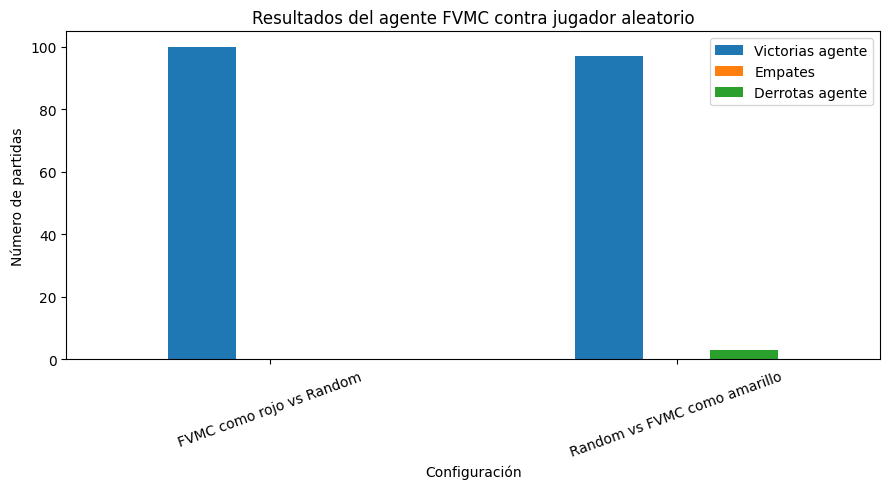

In [7]:
plot_df = random_results_df.set_index("Configuración")[
    ["Victorias agente", "Empates", "Derrotas agente"]
]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Resultados del agente FVMC contra jugador aleatorio")
ax.set_ylabel("Número de partidas")
ax.set_xlabel("Configuración")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Impacto del número de partidas de entrenamiento

Este experimento analiza una variable numérica de configuración: **cantidad de episodios de entrenamiento FVMC**.

Se entrenan varias versiones del mismo agente con diferentes cantidades de partidas simuladas. Luego se evalúa cada versión contra el jugador aleatorio.

Para que el notebook se pueda ejecutar rápido durante revisión, se puede empezar con valores pequeños. Para la versión final, se pueden usar valores más grandes como `500`, `1000`, `5000` y `10000`.


In [8]:
def create_trained_agent(num_episodes: int, epsilon: float = 0.2):
    """
    Crea un agente FVMC entrenado desde cero con num_episodes por cada color.
    No guarda la tabla Q en disco; solo la usa para el experimento.
    """
    agent = FVMCConnect4Agent()
    agent.Q = {}
    agent.returns_count = {}

    agent.train_fvmc(num_episodes=num_episodes, epsilon=epsilon, agent_piece=-1)
    agent.train_fvmc(num_episodes=num_episodes, epsilon=epsilon, agent_piece=1)

    return agent


class FixedAgentFactory:
    """
    Permite reutilizar un mismo agente entrenado sin volver a entrenarlo
    antes de cada partida.
    """

    def __init__(self, agent):
        self.agent = agent

    def __call__(self):
        return self.agent


In [9]:
# Para revisión rápida se puede usar [100, 300, 500].
# Para la entrega final se recomienda usar [500, 1000, 5000, 10000],
# teniendo en cuenta que puede tardar más.

TRAINING_EPISODES = [500, 1000, 5000, 10000]
N_GAMES_PER_CONFIG = 100
EPSILON = 0.2

training_results = []

for episodes in TRAINING_EPISODES:
    print(f"Entrenando agente con {episodes} episodios por color...")
    trained_agent = create_trained_agent(num_episodes=episodes, epsilon=EPSILON)
    agent_factory = FixedAgentFactory(trained_agent)

    print("Evaluando como rojo...")
    as_red = evaluate_match(
        red_policy_factory=agent_factory,
        yellow_policy_factory=lambda: RandomAgent(),
        n_games=N_GAMES_PER_CONFIG,
        seed=episodes + 10
    )

    print("Evaluando como amarillo...")
    as_yellow = evaluate_match(
        red_policy_factory=lambda: RandomAgent(),
        yellow_policy_factory=agent_factory,
        n_games=N_GAMES_PER_CONFIG,
        seed=episodes + 20
    )

    training_results.append({
        "episodes_per_color": episodes,
        "epsilon": EPSILON,
        "q_table_size": len(trained_agent.Q),
        "win_rate_as_red": as_red["red_win_rate"],
        "draw_rate_as_red": as_red["draw_rate"],
        "loss_rate_as_red": as_red["yellow_win_rate"],
        "win_rate_as_yellow": as_yellow["yellow_win_rate"],
        "draw_rate_as_yellow": as_yellow["draw_rate"],
        "loss_rate_as_yellow": as_yellow["red_win_rate"],
    })

training_df = pd.DataFrame(training_results)
training_df


Entrenando agente con 500 episodios por color...
Evaluando como rojo...
Evaluando como amarillo...
Entrenando agente con 1000 episodios por color...
Evaluando como rojo...
Evaluando como amarillo...
Entrenando agente con 5000 episodios por color...
Evaluando como rojo...
Evaluando como amarillo...
Entrenando agente con 10000 episodios por color...
Evaluando como rojo...
Evaluando como amarillo...


,episodes_per_color,epsilon,q_table_size,win_rate_as_red,draw_rate_as_red,loss_rate_as_red,win_rate_as_yellow,draw_rate_as_yellow,loss_rate_as_yellow
0,500,0.2,98802,1.00,0.0,0.00,1.00,0.0,0.00
1,1000,0.2,98802,0.98,0.0,0.02,1.00,0.0,0.00
2,5000,0.2,98802,0.98,0.0,0.02,1.00,0.0,0.00
3,10000,0.2,98802,1.00,0.0,0.00,0.96,0.0,0.04


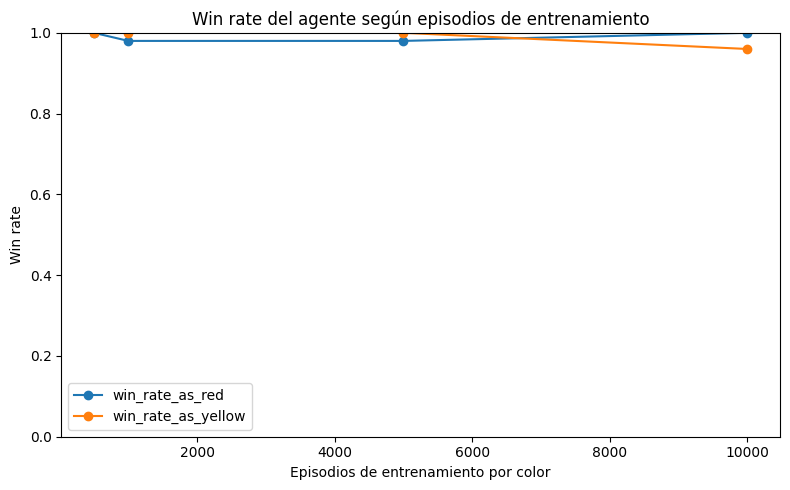

In [10]:
ax = training_df.plot(
    x="episodes_per_color",
    y=["win_rate_as_red", "win_rate_as_yellow"],
    marker="o",
    figsize=(8, 5)
)

ax.set_title("Win rate del agente según episodios de entrenamiento")
ax.set_xlabel("Episodios de entrenamiento por color")
ax.set_ylabel("Win rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

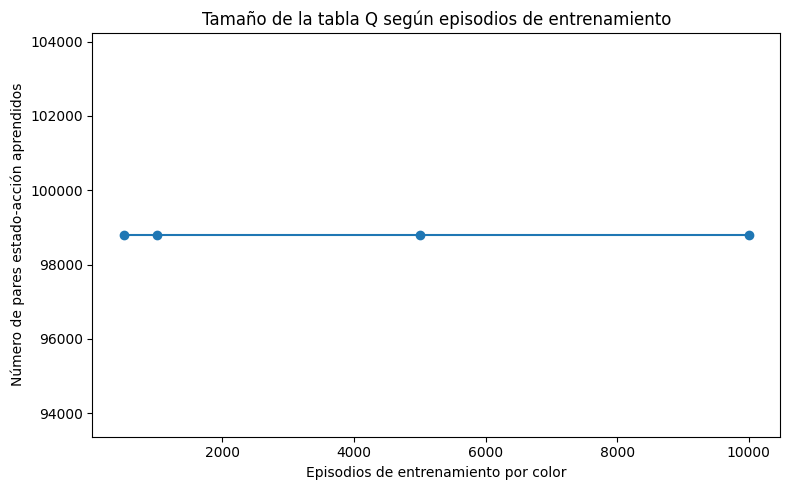

In [11]:
ax = training_df.plot(
    x="episodes_per_color",
    y="q_table_size",
    marker="o",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("Tamaño de la tabla Q según episodios de entrenamiento")
ax.set_xlabel("Episodios de entrenamiento por color")
ax.set_ylabel("Número de pares estado-acción aprendidos")
plt.tight_layout()
plt.show()

## 7. Agente contra sí mismo

La rúbrica también pide analizar el autodesempeño del agente. Para esto se juega FVMC contra FVMC usando la misma política para ambos colores.

Este análisis ayuda a observar si existe ventaja por jugar primero y si la estrategia aprendida produce muchos empates o resultados desbalanceados.

In [12]:
self_play_result = evaluate_match(
    red_policy_factory=lambda: FVMCConnect4Agent(),
    yellow_policy_factory=lambda: FVMCConnect4Agent(),
    n_games=N_GAMES,
    seed=300
)

self_play_df = pd.DataFrame([
    {
        "Resultado": "Gana rojo",
        "Partidas": self_play_result["red_wins"],
    },
    {
        "Resultado": "Gana amarillo",
        "Partidas": self_play_result["yellow_wins"],
    },
    {
        "Resultado": "Empate",
        "Partidas": self_play_result["draws"],
    },
])

self_play_df

,Resultado,Partidas
0,Gana rojo,100
1,Gana amarillo,0
2,Empate,0


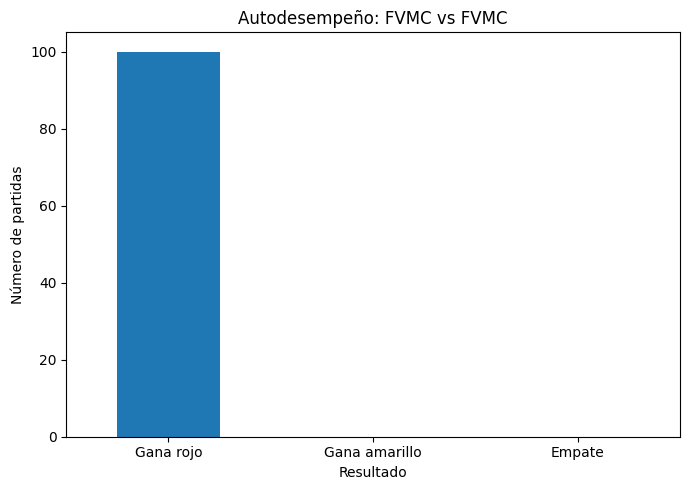

In [13]:
ax = self_play_df.set_index("Resultado").plot(
    kind="bar",
    legend=False,
    figsize=(7, 5)
)

ax.set_title("Autodesempeño: FVMC vs FVMC")
ax.set_ylabel("Número de partidas")
ax.set_xlabel("Resultado")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()